In [1]:
print("Model Training & Evaluation")
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import pickle
import time

from sklearn.linear_model    import LinearRegression, Ridge, Lasso
from sklearn.ensemble        import RandomForestRegressor
from sklearn.metrics         import (mean_squared_error,
                                     mean_absolute_error,
                                     r2_score)
from sklearn.model_selection import cross_val_score, KFold


from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi']        = 130
plt.rcParams['figure.facecolor']  = 'white'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# ── Load all splits ──────────────────────────────────────────
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Unscaled versions for tree-based models
X_train_raw = pd.read_csv('../data/processed/X_train_unscaled.csv')
X_test_raw  = pd.read_csv('../data/processed/X_test_unscaled.csv')

print("Data loaded successfully!")
print(f"  X_train (scaled):   {X_train.shape}")
print(f"  X_test  (scaled):   {X_test.shape}")
print(f"  X_train (unscaled): {X_train_raw.shape}")
print(f"  y_train:            {y_train.shape}")
print(f"  y_test:             {y_test.shape}")
print(f"\nReminder: y is log(Selling_Price)")
print(f"  Reverse with np.expm1(y_pred) to get Lakhs")

Model Training & Evaluation
Data loaded successfully!
  X_train (scaled):   (232, 8)
  X_test  (scaled):   (59, 8)
  X_train (unscaled): (232, 8)
  y_train:            (232,)
  y_test:             (59,)

Reminder: y is log(Selling_Price)
  Reverse with np.expm1(y_pred) to get Lakhs


In [2]:
# ============================================================
# EVALUATION FRAMEWORK
# ============================================================
# Before training a single model, we define HOW we will
# measure success. This prevents cherry-picking metrics
# after the fact — a common form of scientific dishonesty.
#
# THREE METRICS we will use:
#
# 1. R² (R-squared) — "How much variance does my model explain?"
#    Range: 0 to 1  (1.0 = perfect, 0 = predicts the mean)
#    Industry standard: > 0.85 is good for used car pricing
#
# 2. RMSE (Root Mean Squared Error) — "On average, how many
#    Lakhs off is my prediction?"
#    Lower is better. Same units as the target (Lakhs).
#    Penalises large errors more than small ones.
#
# 3. MAE (Mean Absolute Error) — "Average absolute error in Lakhs"
#    Lower is better. More interpretable than RMSE.
#    All errors weighted equally.
#
# Measure on LOG scale for training, but report errors
# in ACTUAL Lakhs for interpretability.

def evaluate_model(model_name, y_true, y_pred_log,
                   training_time=None):
    """
    Evaluate a regression model and return a results dictionary.

    Parameters:
        model_name    : str   — name for display
        y_true        : array — actual log-transformed prices
        y_pred_log    : array — predicted log-transformed prices
        training_time : float — seconds taken to train

    Returns:
        dict with all metrics, plus actual-scale RMSE and MAE
    """
    # Metrics on log scale (what the model sees)
    r2   = r2_score(y_true, y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred_log))
    mae  = mean_absolute_error(y_true, y_pred_log)

    # Reverse log transform → actual Lakhs for reporting
    y_true_actual = np.expm1(y_true)
    y_pred_actual = np.expm1(y_pred_log)

    rmse_actual = np.sqrt(mean_squared_error(
                            y_true_actual, y_pred_actual))
    mae_actual  = mean_absolute_error(y_true_actual, y_pred_actual)

    results = {
        'Model':        model_name,
        'R²':           round(r2,   4),
        'RMSE_log':     round(rmse, 4),
        'MAE_log':      round(mae,  4),
        'RMSE_Lakhs':   round(rmse_actual, 4),
        'MAE_Lakhs':    round(mae_actual,  4),
        'Train_time_s': round(training_time, 3) if training_time else None
    }

    # Pretty print
    stars = '⭐' * (1 + int(r2 > 0.80) + int(r2 > 0.90) + int(r2 > 0.95))
    print(f"\n{'='*50}")
    print(f"  {model_name}  {stars}")
    print(f"{'='*50}")
    print(f"  R²  Score       : {r2:.4f}  "
          f"({'Excellent' if r2>.90 else 'Good' if r2>.80 else 'Fair'})")
    print(f"  RMSE (log)      : {rmse:.4f}")
    print(f"  MAE  (log)      : {mae:.4f}")
    print(f"  RMSE (Lakhs)    : ₹{rmse_actual:.2f}L "
          f"← avg prediction error")
    print(f"  MAE  (Lakhs)    : ₹{mae_actual:.2f}L")
    if training_time:
        print(f"  Training time   : {training_time:.3f}s")

    return results


# Store all results here for comparison later
all_results = []
print("Evaluation framework ready.")
print("We will train 3 models and compare them fairly.")

Evaluation framework ready.
We will train 3 models and compare them fairly.


In [3]:
# ============================================================
# UNDERSTAND THE THREE ALGORITHMS BEFORE TRAINING
# ============================================================

print("""
╔══════════════════════════════════════════════════════════════╗
║           THE THREE ALGORITHMS — HOW THEY THINK              ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. LINEAR REGRESSION                                        ║
║     Draws the best straight line through your data.          ║
║     Formula: Price = w1*Age + w2*Kms + w3*Fuel + ...         ║
║     ✅ Fast, interpretable, good baseline                    ║ 
║     ❌ Assumes relationships are LINEAR (rarely true)        
║     Best when: relationships are roughly linear              ║
║                                                              ║
║  2. RANDOM FOREST                                            ║
║     Builds 100s of decision trees on random subsets.         ║
║     Each tree votes; the average vote = prediction.          ║
║     ✅ Handles non-linear patterns, robust to outliers       
║     ✅ Built-in feature importance                          
║     ❌ Slower, less interpretable than linear                
║     Best when: complex non-linear patterns in data           ║
║                                                              ║
║  3. XGBOOST                                                  ║
║     Builds trees SEQUENTIALLY — each tree fixes the          ║
║     errors of the previous one. (Gradient Boosting)          ║
║     ✅ State-of-the-art on tabular data                    
║     ✅ Regularisation prevents overfitting                   
║     ❌ More hyperparameters to tune                          
║     Best when: you need maximum accuracy                     ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║           THE THREE ALGORITHMS — HOW THEY THINK              ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. LINEAR REGRESSION                                        ║
║     Draws the best straight line through your data.          ║
║     Formula: Price = w1*Age + w2*Kms + w3*Fuel + ...         ║
║     ✅ Fast, interpretable, good baseline                    ║ 
║     ❌ Assumes relationships are LINEAR (rarely true)        
║     Best when: relationships are roughly linear              ║
║                                                              ║
║  2. RANDOM FOREST                                            ║
║     Builds 100s of decision trees on random subsets.         ║
║     Each tree votes; the average vote = prediction.          ║
║     ✅ Handles non-linear patterns, robust to outliers       
║     ✅ Built-in feature imp

In [4]:
# ============================================================
# MODEL 1: LINEAR REGRESSION
# ============================================================
# The simplest model. ALWAYS start with the simplest model.
# This is called your BASELINE — every more complex model
# must beat this to justify its complexity.
#
# Linear Regression works by finding weights (coefficients)
# for each feature so that the weighted sum best predicts y.


print("Training Model 1: Linear Regression...")
print("Using scaled features (required for linear models)\n")

# ── Train ────────────────────────────────────────────────────
t0 = time.time()
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)          
training_time = time.time() - t0

# ── Predict ──────────────────────────────────────────────────
lr_train_pred = lr_model.predict(X_train)
lr_test_pred  = lr_model.predict(X_test)

# ── Evaluate ─────────────────────────────────────────────────
lr_results = evaluate_model(
    "Linear Regression",
    y_test, lr_test_pred,
    training_time
)
all_results.append(lr_results)

# ── Coefficients (what did it learn?) ────────────────────────
print("\n── What Linear Regression Learned ──")
coef_df = pd.DataFrame({
    'Feature':     X_train.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

for _, row in coef_df.iterrows():
    direction = '↑ raises price' if row['Coefficient'] > 0 \
                                 else '↓ lowers price'
    print(f"  {row['Feature']:<22}: {row['Coefficient']:+.4f}  "
          f"({direction})")

print(f"\n  Intercept: {lr_model.intercept_:.4f}")
print("\nInterpretation: a coefficient of +0.3 means increasing")
print("that feature by 1 unit raises log(price) by 0.3,")
print(f"which means price increases by {np.expm1(0.3):.2f}x")

# ── Cross-validation ─────────────────────────────────────────
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    lr_model, X_train, y_train,
    cv=cv, scoring='r2'
)
print(f"\n── 5-Fold Cross Validation R² ──")
print(f"  Scores: {cv_scores.round(4)}")
print(f"  Mean:   {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("  (consistent scores = model generalises well)")

Training Model 1: Linear Regression...
Using scaled features (required for linear models)


  Linear Regression  ⭐⭐⭐⭐
  R²  Score       : 0.9745  (Excellent)
  RMSE (log)      : 0.1468
  MAE  (log)      : 0.1257
  RMSE (Lakhs)    : ₹1.71L ← avg prediction error
  MAE  (Lakhs)    : ₹0.92L
  Training time   : 0.058s

── What Linear Regression Learned ──
  Present_Price_log     : +0.6430  (↑ raises price)
  Car_Age               : -0.1719  (↓ lowers price)
  Fuel_Diesel           : +0.1157  (↑ raises price)
  Seller_Type_enc       : -0.0692  (↓ lowers price)
  Fuel_Petrol           : +0.0584  (↑ raises price)
  Kms_Driven_log        : -0.0363  (↓ lowers price)
  Transmission_enc      : -0.0115  (↓ lowers price)
  Owner                 : -0.0024  (↓ lowers price)

  Intercept: 1.3881

Interpretation: a coefficient of +0.3 means increasing
that feature by 1 unit raises log(price) by 0.3,
which means price increases by 0.35x

── 5-Fold Cross Validation R² ──
  Scores: [0.9561 0.9604 0.9651 0

In [5]:
# ============================================================
# MODEL 2: RANDOM FOREST REGRESSOR
# ============================================================
# Random Forest does NOT need scaled features because
# decision trees split on thresholds, not distances.
# using unscaled data
#
# Key hyperparameters:
#   n_estimators  : number of trees (more = better but slower)
#   max_depth     : how deep each tree can grow
#                   (None = unlimited, can overfit)
#   min_samples_split : min samples needed to split a node
#   random_state  : reproducibility

print("Training Model 2: Random Forest...")
print("Using unscaled features (trees don't need scaling)\n")

t0 = time.time()
rf_model = RandomForestRegressor(
    n_estimators     = 200,    
    max_depth        = None,   
    min_samples_split= 5,      
    min_samples_leaf = 2,      
    max_features     = 'sqrt', 
    random_state     = 42,
    n_jobs           = -1     
)
rf_model.fit(X_train_raw, y_train)
training_time = time.time() - t0

rf_train_pred = rf_model.predict(X_train_raw)
rf_test_pred  = rf_model.predict(X_test_raw)

rf_results = evaluate_model(
    "Random Forest",
    y_test, rf_test_pred,
    training_time
)
all_results.append(rf_results)

# ── Overfitting check ─────────────────────────────────────────
train_r2 = r2_score(y_train, rf_train_pred)
test_r2  = r2_score(y_test,  rf_test_pred)
gap      = train_r2 - test_r2
print(f"\n── Overfitting Check ──")
print(f"  Train R²: {train_r2:.4f}")
print(f"  Test  R²: {test_r2:.4f}")
print(f"  Gap:      {gap:.4f}  "
      f"({'⚠️ possible overfit' if gap > 0.1 else '✅ healthy gap'})")
print("  A gap < 0.10 means the model generalises well.")

# ── Feature importance ────────────────────────────────────────
print("\n── Feature Importance (what RF found most useful) ──")
fi_df = pd.DataFrame({
    'Feature':    X_train_raw.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

for _, row in fi_df.iterrows():
    bar = '█' * int(row['Importance'] * 50)
    print(f"  {row['Feature']:<22}: {bar} {row['Importance']:.4f}")

# ── Cross-validation ──────────────────────────────────────────
cv_scores = cross_val_score(
    rf_model, X_train_raw, y_train,
    cv=5, scoring='r2'
)
print(f"\n── 5-Fold Cross Validation R² ──")
print(f"  Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Training Model 2: Random Forest...
Using unscaled features (trees don't need scaling)


  Random Forest  ⭐⭐⭐
  R²  Score       : 0.9067  (Excellent)
  RMSE (log)      : 0.2806
  MAE  (log)      : 0.1712
  RMSE (Lakhs)    : ₹4.70L ← avg prediction error
  MAE  (Lakhs)    : ₹1.73L
  Training time   : 0.412s

── Overfitting Check ──
  Train R²: 0.9718
  Test  R²: 0.9067
  Gap:      0.0650  (✅ healthy gap)
  A gap < 0.10 means the model generalises well.

── Feature Importance (what RF found most useful) ──
  Present_Price_log     : ███████████████████████ 0.4668
  Seller_Type_enc       : ██████████████ 0.2806
  Fuel_Diesel           : ███ 0.0611
  Car_Age               : ██ 0.0592
  Kms_Driven_log        : ██ 0.0540
  Fuel_Petrol           : ██ 0.0445
  Transmission_enc      : █ 0.0316
  Owner                 :  0.0022

── 5-Fold Cross Validation R² ──
  Mean: 0.9322 ± 0.0168


In [6]:
# ============================================================
# MODEL 3: XGBOOST REGRESSOR
# ============================================================
# XGBoost is currently the best algorithm for tabular data.
# It wins most Kaggle competitions involving structured data.
#
# How it differs from Random Forest:
#   RF  builds trees IN PARALLEL (independently)
#   XGB builds trees IN SEQUENCE (each fixes previous errors)
#
# Key hyperparameters:
#   n_estimators   : number of boosting rounds
#   learning_rate  : how much each tree contributes (lower = safer)
#   max_depth      : tree depth (3-6 is usually best)
#   subsample      : fraction of rows each tree sees (prevents overfit)
#   colsample_bytree: fraction of features each tree sees

print("Training Model 3: XGBoost...")
print("Using unscaled features (trees don't need scaling)\n")

t0 = time.time()
xgb_model = XGBRegressor(
    n_estimators      = 300,
    learning_rate     = 0.05,   # small steps = more careful learning
    max_depth         = 5,
    subsample         = 0.8,    # each tree sees 80% of rows
    colsample_bytree  = 0.8,    # each tree sees 80% of features
    reg_alpha         = 0.1,    # L1 regularisation (reduces overfit)
    reg_lambda        = 1.0,    # L2 regularisation
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0       # suppress training output
)
xgb_model.fit(
    X_train_raw, y_train,
    eval_set=[(X_test_raw, y_test)],  # watch test performance
    verbose=False
)
training_time = time.time() - t0

xgb_train_pred = xgb_model.predict(X_train_raw)
xgb_test_pred  = xgb_model.predict(X_test_raw)

xgb_results = evaluate_model(
    "XGBoost",
    y_test, xgb_test_pred,
    training_time
)
all_results.append(xgb_results)

# ── Overfitting check ─────────────────────────────────────────
train_r2 = r2_score(y_train, xgb_train_pred)
test_r2  = r2_score(y_test,  xgb_test_pred)
gap      = train_r2 - test_r2
print(f"\n── Overfitting Check ──")
print(f"  Train R²: {train_r2:.4f}")
print(f"  Test  R²: {test_r2:.4f}")
print(f"  Gap:      {gap:.4f}  "
      f"({'⚠️ possible overfit' if gap > 0.1 else '✅ healthy gap'})")

# ── Feature importance ────────────────────────────────────────
print("\n── XGBoost Feature Importance ──")
fi_df = pd.DataFrame({
    'Feature':    X_train_raw.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

for _, row in fi_df.iterrows():
    bar = '█' * int(row['Importance'] * 50)
    print(f"  {row['Feature']:<22}: {bar} {row['Importance']:.4f}")

# ── Cross-validation ──────────────────────────────────────────
cv_scores = cross_val_score(
    xgb_model, X_train_raw, y_train,
    cv=5, scoring='r2'
)
print(f"\n── 5-Fold Cross Validation R² ──")
print(f"  Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Training Model 3: XGBoost...
Using unscaled features (trees don't need scaling)


  XGBoost  ⭐⭐⭐
  R²  Score       : 0.9424  (Excellent)
  RMSE (log)      : 0.2205
  MAE  (log)      : 0.1140
  RMSE (Lakhs)    : ₹4.01L ← avg prediction error
  MAE  (Lakhs)    : ₹1.22L
  Training time   : 0.239s

── Overfitting Check ──
  Train R²: 0.9981
  Test  R²: 0.9424
  Gap:      0.0557  (✅ healthy gap)

── XGBoost Feature Importance ──
  Seller_Type_enc       : █████████████████████████████████ 0.6661
  Present_Price_log     : ██████████ 0.2096
  Fuel_Diesel           : ███ 0.0601
  Car_Age               : █ 0.0302
  Transmission_enc      : █ 0.0218
  Kms_Driven_log        :  0.0076
  Fuel_Petrol           :  0.0042
  Owner                 :  0.0004

── 5-Fold Cross Validation R² ──
  Mean: 0.9707 ± 0.0060


In [7]:
# ============================================================
# HEAD-TO-HEAD MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(all_results).set_index('Model')

print("\n" + "="*65)
print("  FINAL MODEL COMPARISON")
print("="*65)
print(results_df[['R²','RMSE_Lakhs','MAE_Lakhs',
                   'Train_time_s']].to_string())
print("="*65)

# Find winner
best_model = results_df['R²'].idxmax()
best_r2    = results_df['R²'].max()
print(f"\n🏆 WINNER: {best_model}  (R² = {best_r2:.4f})")

# What good metrics look like
print("""
── How to interpret these numbers ──

  R² = 0.95 means the model explains 95% of price variation.
       The remaining 5% is noise or unmeasured factors.

  RMSE = ₹1.5L means on average your prediction is
         ₹1.5 Lakhs off from the real price.

  For a used car priced at ₹5L:
    RMSE ₹1.5L = 30% error  (acceptable for used cars)
    RMSE ₹0.8L = 16% error  (good)
    RMSE ₹0.4L = 8%  error  (excellent)
""")


  FINAL MODEL COMPARISON
                       R²  RMSE_Lakhs  MAE_Lakhs  Train_time_s
Model                                                         
Linear Regression  0.9745      1.7100     0.9209         0.058
Random Forest      0.9067      4.6966     1.7263         0.412
XGBoost            0.9424      4.0078     1.2204         0.239

🏆 WINNER: Linear Regression  (R² = 0.9745)

── How to interpret these numbers ──

  R² = 0.95 means the model explains 95% of price variation.
       The remaining 5% is noise or unmeasured factors.

  RMSE = ₹1.5L means on average your prediction is
         ₹1.5 Lakhs off from the real price.

  For a used car priced at ₹5L:
    RMSE ₹1.5L = 30% error  (acceptable for used cars)
    RMSE ₹0.8L = 16% error  (good)
    RMSE ₹0.4L = 8%  error  (excellent)



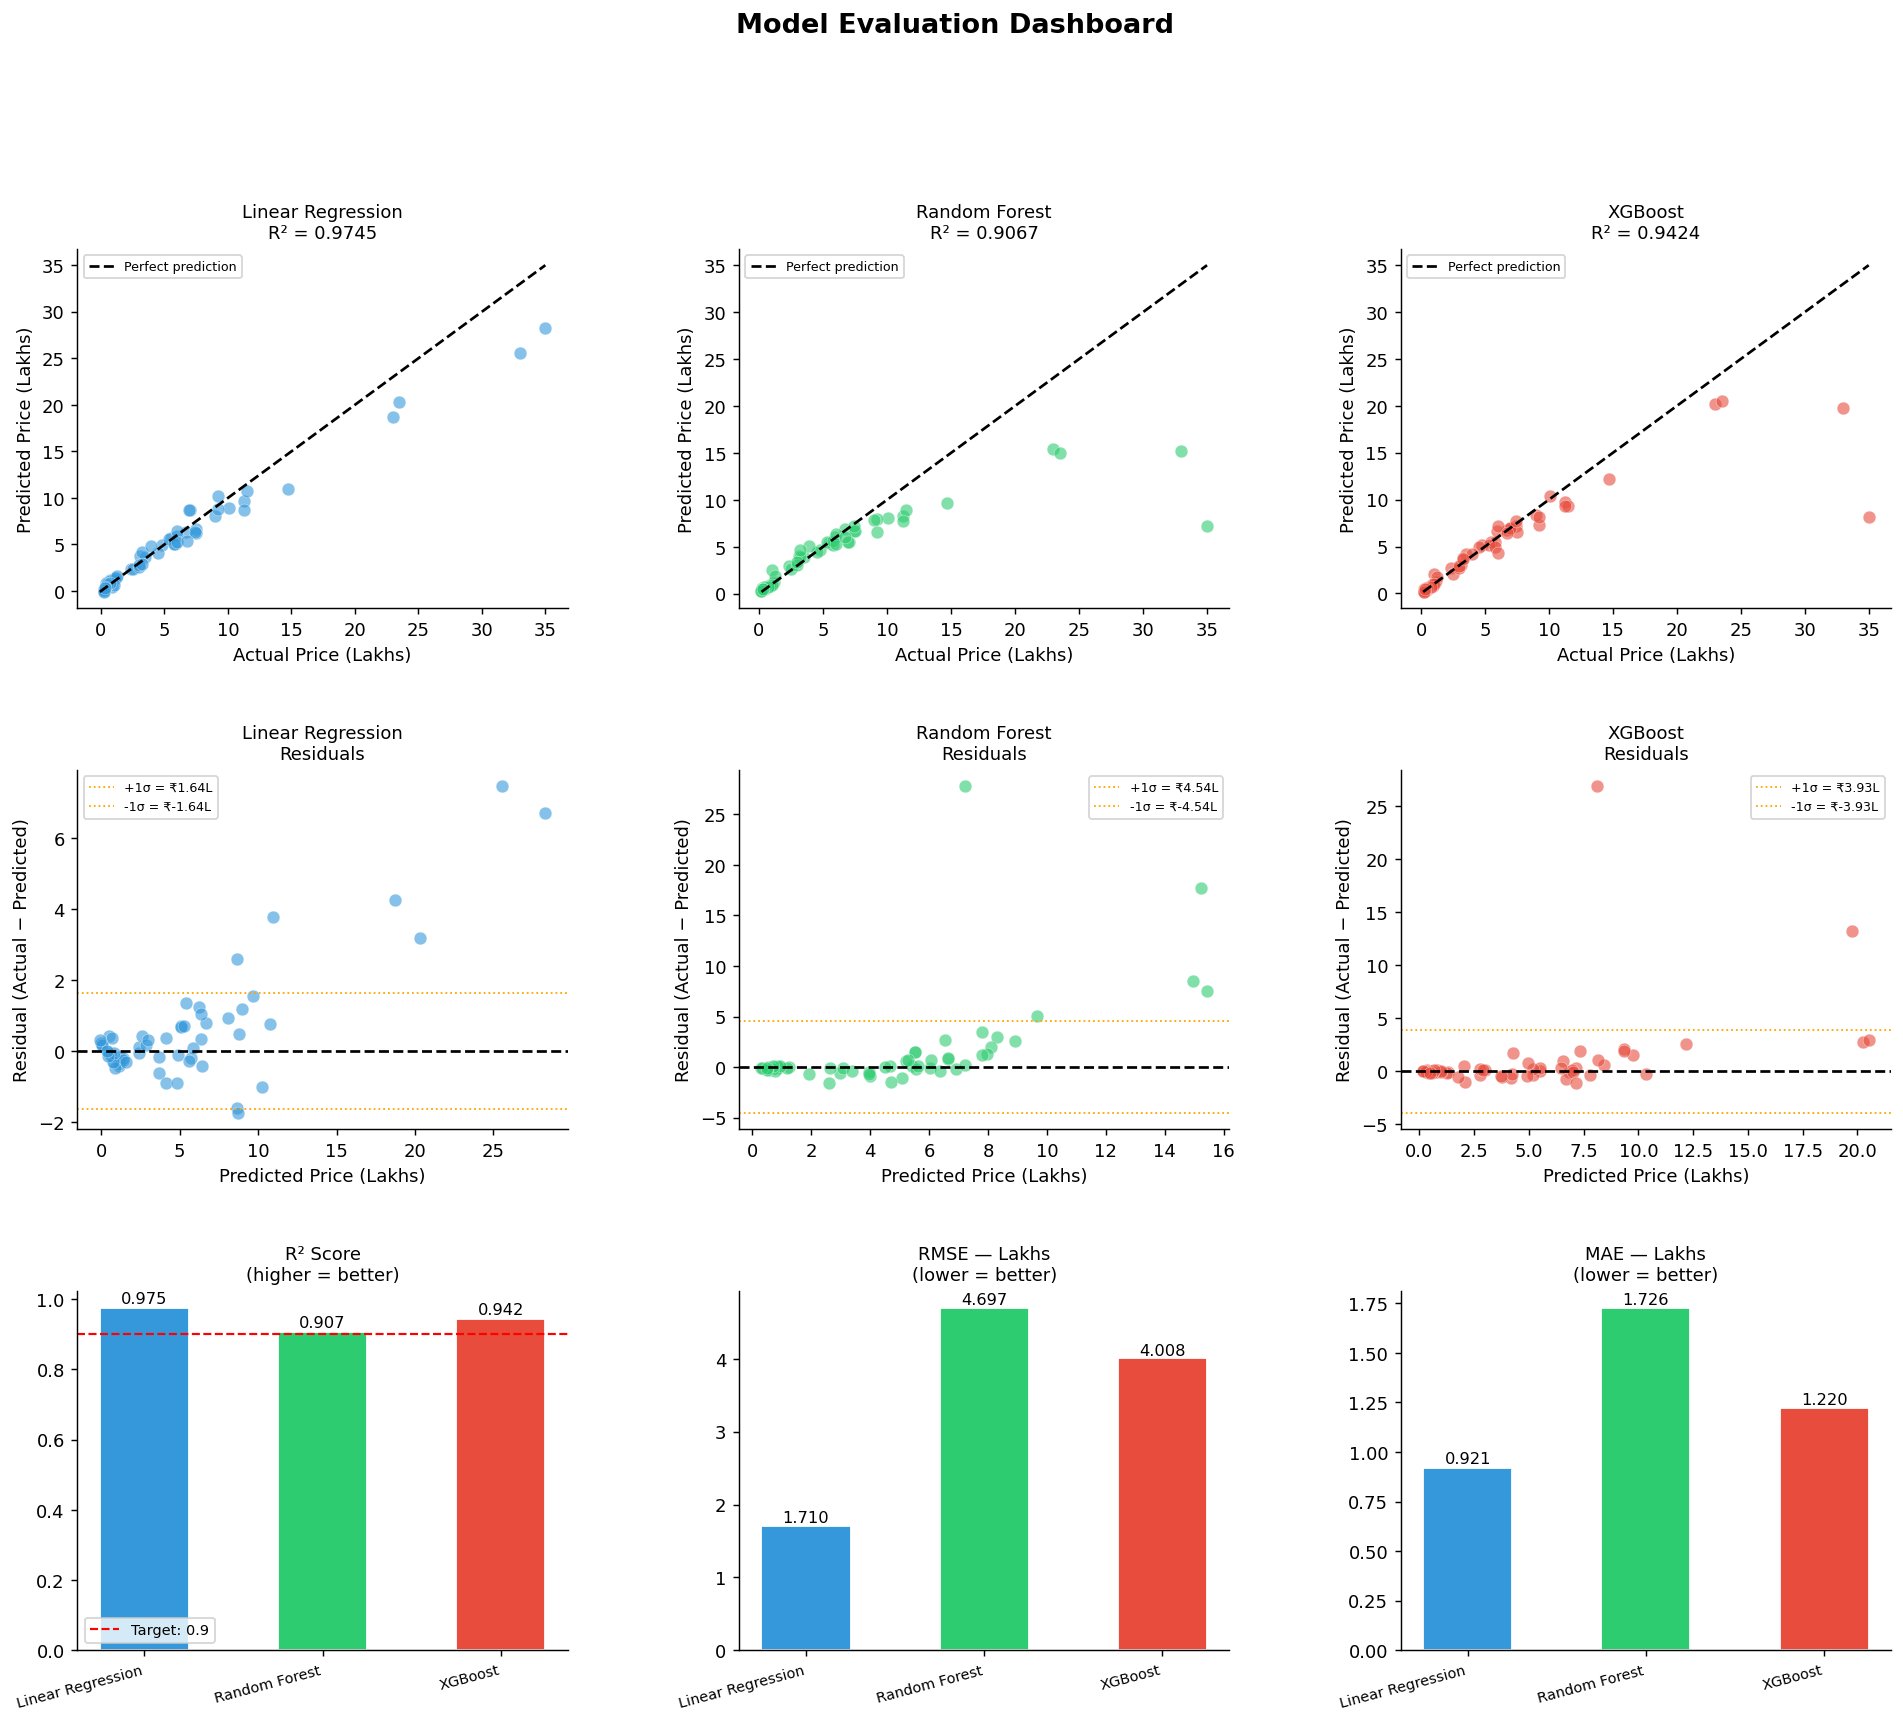

Dashboard saved.


In [8]:
# ============================================================
# EVALUATION VISUALISATIONS
# ============================================================

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('Model Evaluation Dashboard',
             fontsize=15, fontweight='bold', y=1.01)

models_info = [
    ("Linear Regression", lr_test_pred,  '#3498DB'),
    ("Random Forest",     rf_test_pred,  '#2ECC71'),
    ("XGBoost",           xgb_test_pred, '#E74C3C'),
]

# ── Row 1: Actual vs Predicted scatter for each model ────────
for col, (name, pred, color) in enumerate(models_info):
    ax = fig.add_subplot(gs[0, col])

    actual_lakhs = np.expm1(y_test)
    pred_lakhs   = np.expm1(pred)

    ax.scatter(actual_lakhs, pred_lakhs,
               alpha=0.6, color=color, edgecolor='white',
               linewidth=0.3, s=50)

    # Perfect prediction line
    mn = min(actual_lakhs.min(), pred_lakhs.min())
    mx = max(actual_lakhs.max(), pred_lakhs.max())
    ax.plot([mn, mx], [mn, mx], 'k--',
            linewidth=1.5, label='Perfect prediction')

    r2 = r2_score(y_test, pred)
    ax.set_title(f'{name}\nR² = {r2:.4f}', fontsize=10)
    ax.set_xlabel('Actual Price (Lakhs)')
    ax.set_ylabel('Predicted Price (Lakhs)')
    ax.legend(fontsize=7)

# ── Row 2: Residuals plots ───────────────────────────────────
for col, (name, pred, color) in enumerate(models_info):
    ax = fig.add_subplot(gs[1, col])

    residuals = np.expm1(y_test) - np.expm1(pred)
    ax.scatter(np.expm1(pred), residuals,
               alpha=0.6, color=color,
               edgecolor='white', linewidth=0.3, s=50)
    ax.axhline(y=0, color='black', linewidth=1.5,
               linestyle='--')
    ax.axhline(y=residuals.std(),  color='orange',
               linestyle=':', linewidth=1,
               label=f'+1σ = ₹{residuals.std():.2f}L')
    ax.axhline(y=-residuals.std(), color='orange',
               linestyle=':', linewidth=1,
               label=f'-1σ = ₹{-residuals.std():.2f}L')

    ax.set_title(f'{name}\nResiduals', fontsize=10)
    ax.set_xlabel('Predicted Price (Lakhs)')
    ax.set_ylabel('Residual (Actual − Predicted)')
    ax.legend(fontsize=7)

# ── Row 3: Metric comparison bars ───────────────────────────
model_names = [r['Model'] for r in all_results]
r2_scores   = [r['R²']         for r in all_results]
rmse_scores = [r['RMSE_Lakhs'] for r in all_results]
mae_scores  = [r['MAE_Lakhs']  for r in all_results]
colors      = ['#3498DB', '#2ECC71', '#E74C3C']

ax_r2   = fig.add_subplot(gs[2, 0])
ax_rmse = fig.add_subplot(gs[2, 1])
ax_mae  = fig.add_subplot(gs[2, 2])

for ax, metric, values, title, goal in [
    (ax_r2,   model_names, r2_scores,
     'R² Score\n(higher = better)', 0.9),
    (ax_rmse, model_names, rmse_scores,
     'RMSE — Lakhs\n(lower = better)', None),
    (ax_mae,  model_names, mae_scores,
     'MAE — Lakhs\n(lower = better)', None),
]:
    bars = ax.bar(metric, values, color=colors,
                  edgecolor='white', width=0.5)
    if goal:
        ax.axhline(y=goal, color='red', linestyle='--',
                   linewidth=1.2, label=f'Target: {goal}')
        ax.legend(fontsize=8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}',
                ha='center', va='bottom', fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.set_xticks(range(len(metric)))
    ax.set_xticklabels(metric, rotation=15,
                       ha='right', fontsize=8)

plt.savefig('../data/processed/eval_01_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved.")

Linear Regression:
  Mean error:         +0.98%
  Within ±10% error:  28.8% of predictions
  Within ±20% error:  59.3% of predictions

Random Forest:
  Mean error:         -10.51%
  Within ±10% error:  28.8% of predictions
  Within ±20% error:  50.8% of predictions

XGBoost:
  Mean error:         -1.11%
  Within ±10% error:  42.4% of predictions
  Within ±20% error:  79.7% of predictions



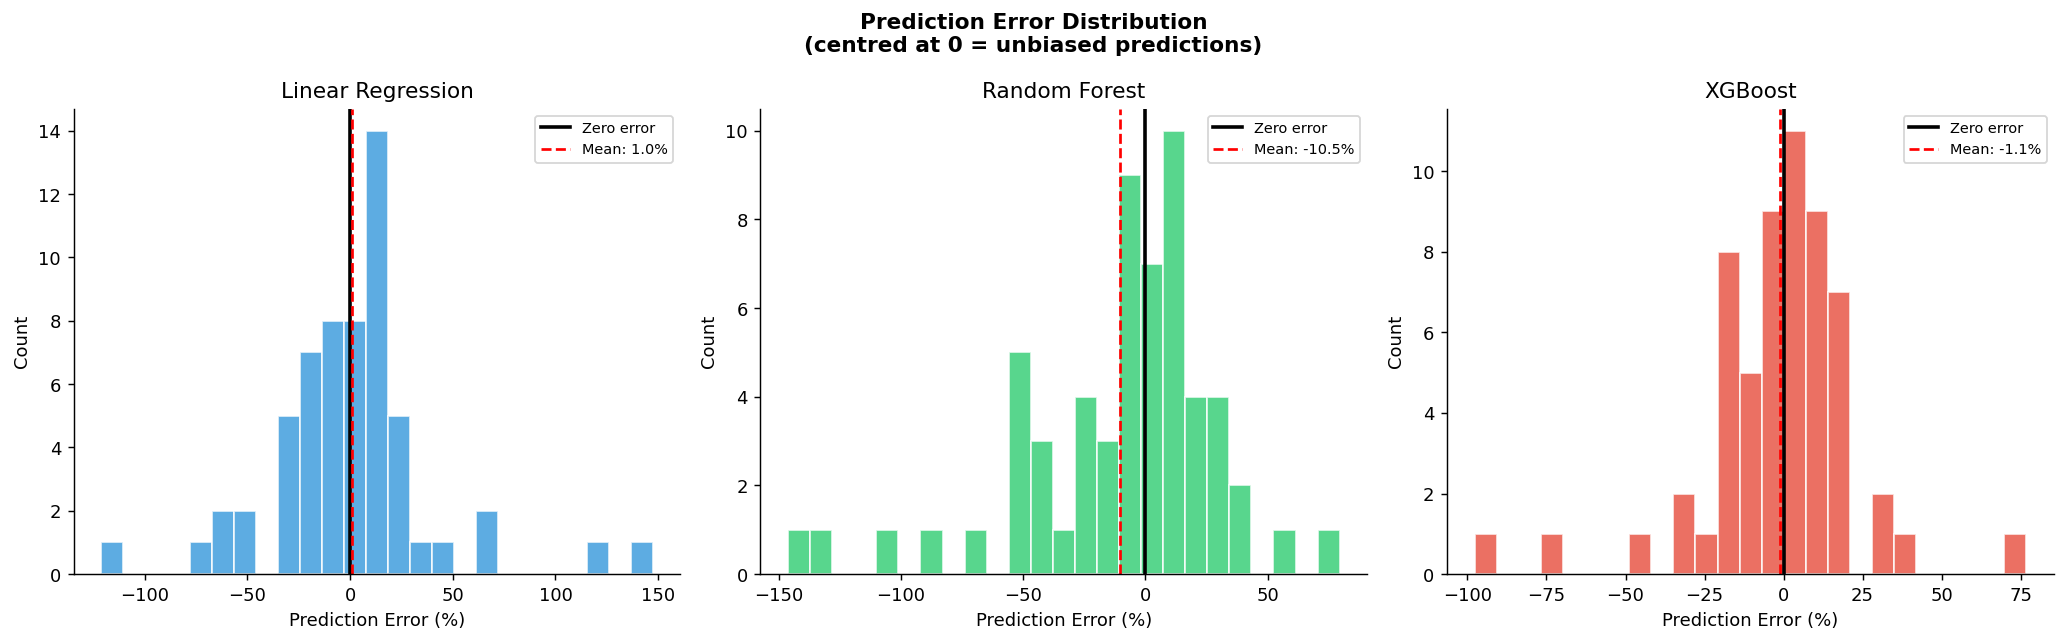

In [9]:
# ============================================================
# ERROR DISTRIBUTION — WHERE DOES EACH MODEL STRUGGLE?
# ============================================================
# A good model has errors centred at 0 with a tight,
# symmetric bell shape. Skewed errors reveal systematic bias.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Prediction Error Distribution\n'
             '(centred at 0 = unbiased predictions)',
             fontsize=12, fontweight='bold')

for ax, (name, pred, color) in zip(axes, models_info):
    residuals_pct = (
        (np.expm1(y_test) - np.expm1(pred))
        / np.expm1(y_test) * 100
    )
    ax.hist(residuals_pct, bins=25, color=color,
            edgecolor='white', alpha=0.8)
    ax.axvline(x=0,   color='black', linewidth=2,
               linestyle='-',  label='Zero error')
    ax.axvline(x=residuals_pct.mean(),
               color='red',   linewidth=1.5,
               linestyle='--',
               label=f'Mean: {residuals_pct.mean():.1f}%')

    ax.set_title(f'{name}')
    ax.set_xlabel('Prediction Error (%)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

    # Print stats below
    within_10 = (residuals_pct.abs() < 10).mean() * 100
    within_20 = (residuals_pct.abs() < 20).mean() * 100
    print(f"{name}:")
    print(f"  Mean error:         {residuals_pct.mean():+.2f}%")
    print(f"  Within ±10% error:  {within_10:.1f}% of predictions")
    print(f"  Within ±20% error:  {within_20:.1f}% of predictions\n")

plt.tight_layout()
plt.savefig('../data/processed/eval_02_error_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ============================================================
# SAMPLE PREDICTIONS vs REALITY
# ============================================================
# Abstract metrics are hard to feel. This table makes
# model performance concrete and understandable.

print("="*80)
print("SAMPLE PREDICTIONS vs ACTUAL PRICES")
print("="*80)
print(f"{'Actual':>10} {'Lin.Reg':>10} {'Rnd.Frst':>10} "
      f"{'XGBoost':>10} {'Best Err':>10}")
print("-"*80)

actual_prices = np.expm1(y_test).values
lr_prices     = np.expm1(lr_test_pred)
rf_prices     = np.expm1(rf_test_pred)
xgb_prices    = np.expm1(xgb_test_pred)

# Show 15 random samples
np.random.seed(42)
sample_idx = np.random.choice(len(actual_prices), 15, replace=False)
sample_idx = np.sort(sample_idx)

for i in sample_idx:
    actual = actual_prices[i]
    lr_p   = lr_prices[i]
    rf_p   = rf_prices[i]
    xgb_p  = xgb_prices[i]

    errors = {
        'LR':  abs(actual - lr_p),
        'RF':  abs(actual - rf_p),
        'XGB': abs(actual - xgb_p)
    }
    best = min(errors, key=errors.get)

    print(f"  ₹{actual:>6.2f}L  "
          f"₹{lr_p:>6.2f}L  "
          f"₹{rf_p:>6.2f}L  "
          f"₹{xgb_p:>6.2f}L  "
          f"{best} wins (err ₹{errors[best]:.2f}L)")

print("-"*80)


SAMPLE PREDICTIONS vs ACTUAL PRICES
    Actual    Lin.Reg   Rnd.Frst    XGBoost   Best Err
--------------------------------------------------------------------------------
  ₹ 11.25L  ₹  9.69L  ₹  8.31L  ₹  9.75L  XGB wins (err ₹1.50L)
  ₹  0.25L  ₹  0.07L  ₹  0.59L  ₹  0.43L  LR wins (err ₹0.18L)
  ₹  0.72L  ₹  1.14L  ₹  0.80L  ₹  0.75L  XGB wins (err ₹0.03L)
  ₹  7.45L  ₹  6.67L  ₹  6.64L  ₹  7.15L  XGB wins (err ₹0.30L)
  ₹  5.50L  ₹  5.70L  ₹  5.43L  ₹  5.49L  XGB wins (err ₹0.01L)
  ₹ 10.11L  ₹  8.94L  ₹  8.11L  ₹ 10.34L  XGB wins (err ₹0.23L)
  ₹ 11.50L  ₹ 10.73L  ₹  8.91L  ₹  9.36L  LR wins (err ₹0.77L)
  ₹  6.95L  ₹  8.70L  ₹  5.51L  ₹  7.00L  XGB wins (err ₹0.05L)
  ₹ 23.50L  ₹ 20.33L  ₹ 14.98L  ₹ 20.52L  XGB wins (err ₹2.98L)
  ₹  4.50L  ₹  4.12L  ₹  4.49L  ₹  4.93L  RF wins (err ₹0.01L)
  ₹  2.35L  ₹  2.41L  ₹  2.99L  ₹  2.74L  LR wins (err ₹0.06L)
  ₹  3.00L  ₹  2.59L  ₹  3.08L  ₹  2.76L  RF wins (err ₹0.08L)
  ₹  0.75L  ₹  0.81L  ₹  0.68L  ₹  0.66L  LR wins (err ₹0.06L)
  

In [ ]:
# ============================================================
# SAVE THE BEST MODEL
# ============================================================

import os
os.makedirs('../models', exist_ok=True)

# Determine winner programmatically
best_name = results_df['R²'].idxmax()
print(f"Best model: {best_name}")

# Save all three models
model_map = {
    "Linear Regression": lr_model,
    "Random Forest":     rf_model,
    "XGBoost":           xgb_model,
}

for name, model in model_map.items():
    filename = name.lower().replace(' ', '_')
    path = f'../models/{filename}_model.pkl'
    with open(path, 'wb') as f:
        pickle.dump(model, f)
    print(f"  Saved: {path}")

# Save the best model separately for the app
best_model_obj = model_map[best_name]
with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model_obj, f)

# Save results table
results_df.to_csv('../data/processed/model_results.csv')

print(f"\nAll models saved to models/")
print(f"Best model ({best_name}) saved as: models/best_model.pkl")
print("\nSaved files:")
for f in os.listdir('../models'):
    size = os.path.getsize(f'../models/{f}') / 1024
    print(f"  models/{f}  ({size:.1f} KB)")